# Week 4 – Predictive Modeling and Optimization in Logistics

## Objective

The objective of this analysis is to build predictive machine learning models
for estimating delivery time using logistics-related features and to evaluate
their performance for operational decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("Zomato_Delivery_Cleaned.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (45584, 33)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,City_was_missing,Multiple_deliveries_was_missing,Weather_was_missing,Traffic_was_missing,Festival_was_missing,Time_Orderd_Clean,Time_Order_picked_Clean,Order_DateTime,Pickup_DateTime,Pickup_Delay_Minutes
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,21:55,...,0,0,0,0,0,21:55:00,22:10:00,2022-02-12 21:55:00.000000000,2022-02-12 22:10:00.000000000,15.0
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,14:55,...,0,0,0,0,0,14:55:00,15:05:00,2022-02-13 14:55:00.000000000,2022-02-13 15:05:00.000000000,10.0
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,17:30,...,0,0,0,0,0,17:30:00,17:40:00,2022-03-04 17:30:00.000000000,2022-03-04 17:40:00.000000000,10.0
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,09:20,...,0,0,0,0,0,09:20:00,09:30:00,2022-02-13 09:20:00.000000000,2022-02-13 09:30:00.000000000,10.0
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,19:50,...,0,0,0,0,0,19:50:00,20:05:00,2022-02-14 19:50:00.000000000,2022-02-14 20:05:00.000000000,15.0


## Feature Selection

Relevant logistics features are selected for predicting delivery time.
Identifier fields and unnecessary raw variables are excluded from the
initial predictive model.

In [3]:
features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Weather_conditions",
    "Road_traffic_density",
    "Vehicle_condition",
    "Type_of_order",
    "Type_of_vehicle",
    "multiple_deliveries",
    "Festival",
    "City"
]

target = "Time_taken (min)"

model_df = df[features + [target]].copy()

print("Model Dataset Shape:", model_df.shape)
model_df.head()

Model Dataset Shape: (45584, 11)


,Delivery_person_Age,Delivery_person_Ratings,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,36.0,4.2,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,21.0,4.7,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,23.0,4.7,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,34.0,4.3,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,24.0,4.7,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


## Data Preparation

The selected features are checked for data types and missing values before
preprocessing and model training.

In [4]:
print("Data Types:")
print(model_df.dtypes)

print("\nMissing Values:")
print(model_df.isnull().sum())

Data Types:
Delivery_person_Age        float64
Delivery_person_Ratings    float64
Weather_conditions             str
Road_traffic_density           str
Vehicle_condition            int64
Type_of_order                  str
Type_of_vehicle                str
multiple_deliveries        float64
Festival                       str
City                           str
Time_taken (min)             int64
dtype: object

Missing Values:
Delivery_person_Age           0
Delivery_person_Ratings    1908
Weather_conditions            0
Road_traffic_density          0
Vehicle_condition             0
Type_of_order                 0
Type_of_vehicle               0
multiple_deliveries           0
Festival                      0
City                          0
Time_taken (min)              0
dtype: int64


### Handling Missing Values

The Delivery_person_Ratings column contains 1,908 missing values.
These missing values are replaced with the median rating to preserve the
records while reducing the influence of extreme values.

In [6]:
rating_median = model_df["Delivery_person_Ratings"].median()

model_df["Delivery_person_Ratings"] = (
    model_df["Delivery_person_Ratings"].fillna(rating_median)
)

print("Median Rating Used:", rating_median)

print("\nMissing Values After Imputation:")
print(model_df.isnull().sum())

Median Rating Used: 4.7

Missing Values After Imputation:
Delivery_person_Age        0
Delivery_person_Ratings    0
Weather_conditions         0
Road_traffic_density       0
Vehicle_condition          0
Type_of_order              0
Type_of_vehicle            0
multiple_deliveries        0
Festival                   0
City                       0
Time_taken (min)           0
dtype: int64


## Preparing Features and Target

The dataset is divided into input features (X) and the target variable (y).
The target variable is delivery time in minutes.

In [7]:
X = model_df.drop(columns=["Time_taken (min)"])
y = model_df["Time_taken (min)"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (45584, 10)
y Shape: (45584,)


### Train-Test Split

The dataset is divided into training and testing sets.
80% of the data is used for model training and 20% is reserved for
evaluating model performance on unseen data.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

## Data Preprocessing

Numerical and categorical features are processed separately.
Categorical variables are converted into numerical form using One-Hot Encoding
so that they can be used by machine learning models.

In [10]:
numeric_features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Vehicle_condition",
    "multiple_deliveries"
]

categorical_features = [
    "Weather_conditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Delivery_person_Age', 'Delivery_person_Ratings', 'Vehicle_condition', 'multiple_deliveries']

Categorical Features:
['Weather_conditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City']


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Model 1: Linear Regression

Linear Regression is used as the baseline regression model for predicting
delivery time. The preprocessing pipeline and regression model are combined
to ensure consistent transformation of the training and testing data.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE :", round(mae_linear, 2))
print("MSE :", round(mse_linear, 2))
print("RMSE:", round(rmse_linear, 2))
print("R²  :", round(r2_linear, 4))

Linear Regression Performance
--------------------------------
MAE : 4.96
MSE : 38.97
RMSE: 6.24
R²  : 0.5583


## Model 2: Decision Tree Regressor

A Decision Tree Regressor is trained to capture non-linear relationships
between logistics features and delivery time. Its performance is compared
with the Linear Regression baseline.

In [15]:
from sklearn.tree import DecisionTreeRegressor

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=10,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [16]:
y_pred_tree = decision_tree_model.predict(X_test)

mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Performance")
print("--------------------------------")
print("MAE :", round(mae_tree, 2))
print("MSE :", round(mse_tree, 2))
print("RMSE:", round(rmse_tree, 2))
print("R²  :", round(r2_tree, 4))

Decision Tree Performance
--------------------------------
MAE : 4.08
MSE : 27.08
RMSE: 5.2
R²  : 0.693


## Model 3: Random Forest Regressor

Random Forest combines multiple decision trees to improve predictive
performance and reduce the risk of overfitting associated with a single
decision tree.

In [18]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=12,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [19]:
y_pred_rf = random_forest_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("--------------------------------")
print("MAE :", round(mae_rf, 2))
print("MSE :", round(mse_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²  :", round(r2_rf, 4))

Random Forest Performance
--------------------------------
MAE : 3.95
MSE : 25.66
RMSE: 5.07
R²  : 0.7091


## Model Comparison

The performance of Linear Regression, Decision Tree, and Random Forest
models is compared using MAE, RMSE, and R² Score. Lower MAE and RMSE
values and a higher R² score indicate better predictive performance.

In [20]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_tree,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_tree,
        rmse_rf
    ],
    "R2_Score": [
        r2_linear,
        r2_tree,
        r2_rf
    ]
})

model_comparison = model_comparison.round(3)

model_comparison

,Model,MAE,RMSE,R2_Score
0,Linear Regression,4.955,6.242,0.558
1,Decision Tree,4.079,5.204,0.693
2,Random Forest,3.953,5.066,0.709


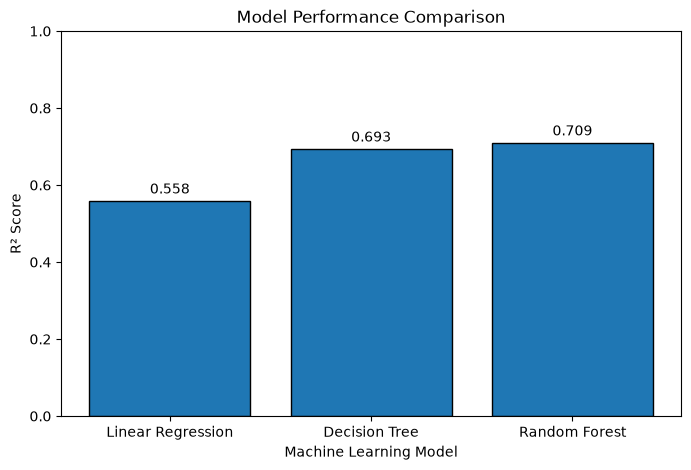

In [21]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    model_comparison["Model"],
    model_comparison["R2_Score"],
    edgecolor="black"
)

plt.title("Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)

for bar, value in zip(bars, model_comparison["R2_Score"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.show()

## Actual vs Predicted Delivery Time

The predictions generated by the best-performing Random Forest model are
compared with the actual delivery times in the test dataset. Predictions
closer to the diagonal reference line indicate better model performance.

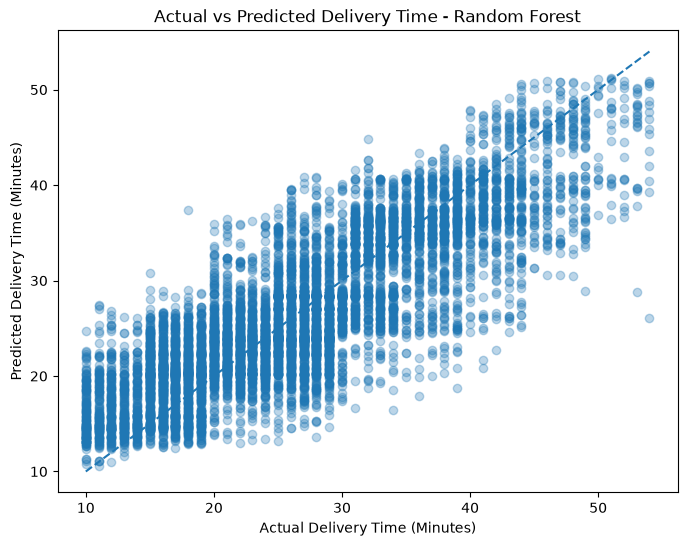

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.3
)

min_value = min(y_test.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Delivery Time - Random Forest")
plt.xlabel("Actual Delivery Time (Minutes)")
plt.ylabel("Predicted Delivery Time (Minutes)")

plt.show()

## Feature Importance Analysis

Feature importance from the Random Forest model is analysed to identify
which logistics variables contribute most to the model's delivery-time
predictions.

In [23]:
# Get the fitted preprocessing step
fitted_preprocessor = random_forest_model.named_steps["preprocessor"]

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get feature importance from Random Forest
importances = random_forest_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(15)

,Feature,Importance
0,num__Delivery_person_Ratings,0.259434
1,num__multiple_deliveries,0.152932
2,cat__Road_traffic_density_Low,0.146629
3,num__Delivery_person_Age,0.108710
4,num__Vehicle_condition,0.102560
5,cat__Weather_conditions_Sunny,0.076246
6,cat__Road_traffic_density_Jam,0.039380
7,cat__Weather_conditions_Cloudy,0.025176
8,cat__Weather_conditions_Fog,0.024454
9,cat__Festival_Yes,0.015241


### Top Predictive Features

The ten most important transformed features from the Random Forest model
are visualized to understand the factors that contribute most to delivery-time
prediction.

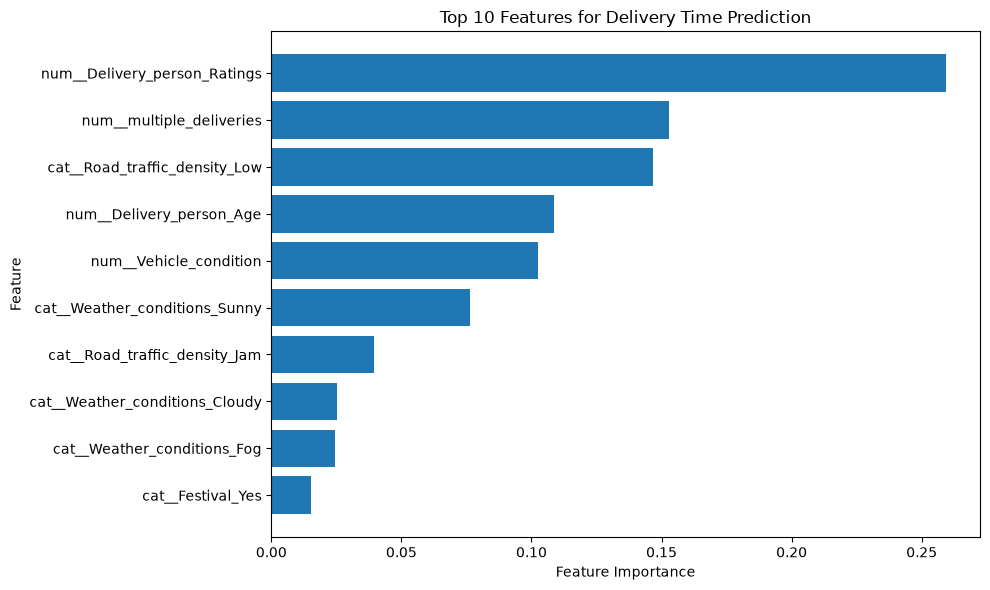

In [25]:
top_features = feature_importance.head(10).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Features for Delivery Time Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Sample Delivery Time Predictions

The best-performing Random Forest model is used to generate delivery-time
predictions for sample records from the test dataset. This demonstrates how
the trained model can be applied to unseen logistics data.

In [27]:
prediction_results = pd.DataFrame({
    "Actual_Delivery_Time": y_test.values,
    "Predicted_Delivery_Time": y_pred_rf
})

prediction_results["Absolute_Error"] = abs(
    prediction_results["Actual_Delivery_Time"] -
    prediction_results["Predicted_Delivery_Time"]
)

prediction_results = prediction_results.round(2)

prediction_results.head(10)

,Actual_Delivery_Time,Predicted_Delivery_Time,Absolute_Error
0,33,37.35,4.35
1,28,24.22,3.78
2,22,18.07,3.93
3,25,20.59,4.41
4,35,33.56,1.44
5,27,18.24,8.76
6,48,46.02,1.98
7,27,33.82,6.82
8,24,18.66,5.34
9,18,21.05,3.05


## Logistics Optimization Recommendations

Based on the exploratory analysis and predictive modeling results, the following operational recommendations can be considered:

1. **Optimize Multiple-Delivery Allocation**  
   Multiple deliveries are an important predictor of delivery time. Delivery workload should be distributed carefully to reduce excessive delays.

2. **Traffic-Aware Route Planning**  
   Road traffic conditions should be incorporated into route selection and estimated delivery-time calculations.

3. **Use Predictive ETA Estimation**  
   The Random Forest model can be used as a prototype for estimating delivery time using information available for a delivery.

4. **Monitor Delivery Personnel Performance**  
   Delivery-person ratings were highly useful to the predictive model. Operational teams can investigate the practices associated with efficient and highly rated delivery personnel.

5. **Weather-Aware Operations**  
   Weather conditions should be considered when planning delivery schedules and communicating estimated arrival times.

6. **Festival Capacity Planning**  
   Additional delivery capacity can be planned during festival periods because the exploratory analysis identified substantially longer delivery times during festivals.

7. **Vehicle Monitoring and Maintenance**  
   Vehicle condition should be monitored as part of delivery operations because it contributes information to delivery-time prediction.

### Model Selection

Among the evaluated models, Random Forest achieved the best performance with an MAE of approximately 3.95 minutes, RMSE of approximately 5.07 minutes, and an R² score of approximately 0.71. Therefore, Random Forest was selected as the best model for this analysis.

These recommendations are based on statistical associations and predictive patterns observed in the dataset and should be validated in a real operational environment before deployment.

## Future Logistics Forecast Simulation

A hypothetical future logistics scenario is simulated using the trained
Random Forest model. The purpose is to demonstrate how the predictive model
could support delivery-time forecasting and operational planning.

In [29]:
future_scenarios = pd.DataFrame({
    "Delivery_person_Age": [25, 30, 35, 28],
    "Delivery_person_Ratings": [4.8, 4.5, 4.2, 4.7],
    "Weather_conditions": ["Sunny", "Fog", "Stormy", "Cloudy"],
    "Road_traffic_density": ["Low", "Jam", "High", "Medium"],
    "Vehicle_condition": [2, 1, 1, 2],
    "Type_of_order": ["Snack", "Meal", "Drinks", "Buffet"],
    "Type_of_vehicle": ["motorcycle", "motorcycle", "scooter", "motorcycle"],
    "multiple_deliveries": [0.0, 1.0, 2.0, 1.0],
    "Festival": ["No", "Yes", "No", "No"],
    "City": ["Urban", "Metropolitian", "Urban", "Metropolitian"]
})

future_scenarios

,Delivery_person_Age,Delivery_person_Ratings,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City
0,25,4.8,Sunny,Low,2,Snack,motorcycle,0.0,No,Urban
1,30,4.5,Fog,Jam,1,Meal,motorcycle,1.0,Yes,Metropolitian
2,35,4.2,Stormy,High,1,Drinks,scooter,2.0,No,Urban
3,28,4.7,Cloudy,Medium,2,Buffet,motorcycle,1.0,No,Metropolitian


In [30]:
future_predictions = random_forest_model.predict(future_scenarios)

future_results = future_scenarios.copy()

future_results["Predicted_Delivery_Time"] = np.round(
    future_predictions, 2
)

future_results[
    [
        "Weather_conditions",
        "Road_traffic_density",
        "multiple_deliveries",
        "Festival",
        "Predicted_Delivery_Time"
    ]
]

,Weather_conditions,Road_traffic_density,multiple_deliveries,Festival,Predicted_Delivery_Time
0,Sunny,Low,0.0,No,19.69
1,Fog,Jam,1.0,Yes,44.25
2,Stormy,High,2.0,No,36.05
3,Cloudy,Medium,1.0,No,24.61


## Final Conclusion

This project developed and evaluated machine learning models for predicting
delivery time in a logistics environment.

The cleaned logistics dataset was prepared by selecting relevant operational
features, handling missing values, encoding categorical variables, and splitting
the data into training and testing sets.

Three regression models were evaluated:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Among these models, Random Forest achieved the best predictive performance,
with an MAE of approximately 3.95 minutes, RMSE of approximately 5.07 minutes,
and an R² score of approximately 0.71.

The analysis also showed that delivery-person characteristics, multiple
deliveries, traffic conditions, vehicle condition, weather conditions, and
festival-related factors provide useful information for delivery-time prediction.

The Actual vs Predicted analysis demonstrated that the Random Forest model
captured a substantial portion of the variation in delivery time, although
prediction errors still remain.

A hypothetical scenario simulation was also performed to demonstrate how the
trained model could be used to estimate delivery times under different logistics
conditions.

From an operational perspective, predictive delivery-time estimation can support
traffic-aware planning, workload allocation, ETA estimation, festival capacity
planning, and other logistics decisions.

Overall, the Random Forest model was selected as the best-performing model in
this analysis. However, the results represent a prototype based on the available
dataset, and further validation with real operational and time-based data would
be required before production deployment.